## Setup

In [ ]:
# imports 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import pandas as pd

from scipy.signal import sosfiltfilt, butter, welch
from scipy.stats import entropy, skew, kurtosis, ks_2samp, wasserstein_distance

os.environ['KERAS_BACKEND'] = 'torch'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import keras
from meegkit import dss

import mne
from mne.time_frequency import psd_array_welch
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data
from src.EEGModalNet.models.FiLMGAN import FiLMGAN


# helper functions
def segment_data(x, time_dim):
    return torch.tensor(x.copy()).unfold(2, time_dim, time_dim).permute(0, 2, 3, 1).flatten(0, 1)

def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)
      
def generate_data(
    model,
    x,
    sub,
    pos,
    n_subjects,
    latent_dim=128,
    use_random_sub=False,
    device=None,
):
    """
    x:      (B, T, C) real data (only used for shape / optional stats later)
    sub:    (B, 1) subject ids for each segment
    pos:    (B, T, D_pos) positional encodings
    """

    model.generator.eval()

    if device is None:
        # infer device from model
        device = next(model.generator.parameters()).device
    else:
        device = torch.device(device)

    x      = x.float().to(device)
    sub    = sub.to(device)
    pos    = pos.to(device)

    B, T, C = x.shape
    x_gen   = torch.zeros_like(x)

    # assume balanced per-subject chunks
    bs = B // n_subjects
    n_chunks = B // bs

    for i in range(n_chunks):
        start = i * bs
        end   = (i + 1) * bs

        if use_random_sub:
            # sample labels uniformly in [0, n_subjects)
            sub_batch = torch.randint(0, n_subjects, (bs, 1), device=device)
        else:
            sub_batch = sub[start:end]

        z = torch.randn(bs, latent_dim, device=device)
        pos_batch = pos[start:end]

        with torch.no_grad():
            x_gen_batch = model.generator((z, sub_batch, pos_batch))
        x_gen[start:end] = x_gen_batch.cpu()

    # handle residual if B not divisible by bs
    tr_sh = (B // bs) * bs
    if tr_sh < B:
        res = B - tr_sh
        print("creating the residuals")

        if use_random_sub:
            sub_batch = torch.randint(0, n_subjects, (res, 1), device=device)
        else:
            sub_batch = sub[-res:]

        z = torch.randn(res, latent_dim, device=device)
        pos_batch = pos[-res:]

        with torch.no_grad():
            x_gen_tail = model.generator((z, sub_batch, pos_batch))
        x_gen[-res:] = x_gen_tail.cpu()

    return x_gen


def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    if reverse_first:
        x = reverse_segmentation(x, n_subjects)
    else:
        x = x.permute(0, 2, 1)
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

def plot_time_domain(x, x_gen, time_dim, channels, ax, ch=0):
    x, x_gen = x[:, ch, :time_dim], x_gen[:, ch, :time_dim]
    real_data_avg = x.mean(0)
    fake_data_avg = x_gen.mean(0)
    ax.plot(fake_data_avg, label="Generated", color='orangered')
    ax.plot(real_data_avg, label="Real", color='navy', alpha=0.5)

    ax.fill_between(np.arange(time_dim),
                    real_data_avg - x.std(axis=0),
                    real_data_avg + x.std(axis=0),
                    alpha=0.4, color='navy')
    
    ax.fill_between(np.arange(time_dim),
            fake_data_avg - x_gen.std(axis=0),
            fake_data_avg + x_gen.std(axis=0),
            alpha=0.4, color='orangered')

    ax.set_title(f'Channel {channels[ch]}', fontsize=14, color='blue', loc='left')
    ax.set_xlim([0, time_dim])


def plot_psd_individual_subjects(reversed_x, channels, ax, n_sub_plotted=2, fmin=1, fmax=60, n_fft=512, color='blue'):
    psd, freq = mne.time_frequency.psd_array_welch(reversed_x[:n_sub_plotted], sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    psd = 10*np.log10(psd)
    for n in range(n_sub_plotted):
        for i, c in enumerate(range(len(channels))):
            psd_ = psd[n, c, :]
            ax[i//4, i%4].plot(freq, psd_, label=f'subject {n}', linewidth=2)
            ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
            ax[i//4, i%4].set_xlim([0.7, fmax])

def calculate_psd_different_methods(x, x_gen, n_subjects, psd_method='reorder_first'):

    if psd_method == 'reverse_first':
        psd, freq = psd_array_welch(reverse_segmentation(x, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(reverse_segmentation(x_gen, n_subjects).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'flat_first':
        psd, freq = psd_array_welch(x.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.flatten(0, 1).permute(1, 0).numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)

    if psd_method == 'reorder_first':
        psd, freq = psd_array_welch(x.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
        psd_gen, freq_gen = psd_array_welch(x_gen.permute(0, 2, 1).numpy(), sfreq=128, fmin=1, fmax=50, n_fft=512, verbose=False)
    
    return psd, psd_gen, freq

def time_domain_features_multi_channel(x, axis=-1):  # x: (n_samples, n_channels, n_timepoints)
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis)
    skewness = skew(x, axis=axis)
    kurtosis_ = kurtosis(x, axis=axis)
    rms = np.sqrt(np.mean(x**2, axis=axis))
    return np.stack([mean, std, skewness, kurtosis_, rms], axis=-1)  # (n_samples, n_channels, n_features)

def hjorth_parameters_multi_channel(signal, axis=-1): 
    activity = np.var(signal, axis=axis)
    first_derivative = np.diff(signal, axis=axis)
    mobility = np.sqrt(np.var(first_derivative, axis=axis) / activity)
    second_derivative = np.diff(first_derivative, axis=axis)
    complexity = np.sqrt(np.var(second_derivative, axis=axis) / np.var(first_derivative, axis=axis)) / mobility
    return np.stack([activity, mobility, complexity], axis=-1)

def spectral_features_multi_channel(signal, fs=128, nperseg=512):
    f, Pxx = welch(signal, fs=fs, nperseg=nperseg, axis=-1)
    total_power = np.sum(Pxx, axis=-1)
    delta = np.sum(Pxx[:, :, (f >= 0.25) & (f < 4)], axis=-1) / total_power
    theta = np.sum(Pxx[:, :, (f >= 4) & (f < 8)], axis=-1) / total_power
    alpha = np.sum(Pxx[:, :, (f >= 8) & (f < 13)], axis=-1) / total_power
    beta = np.sum(Pxx[:, :, (f >= 13) & (f <= 30)], axis=-1) / total_power
    gamma = np.sum(Pxx[:, :, (f > 30) & (f <= 50)], axis=-1) / total_power
    pxx_entropy = entropy(Pxx, axis=-1)
    return np.stack([delta, theta, alpha, beta, gamma, pxx_entropy], axis=-1)

def aggregate_features(real_signal, gen_signal):
    # Extract features
    real_time_features = time_domain_features_multi_channel(real_signal)
    real_hjorth_features = hjorth_parameters_multi_channel(real_signal)
    real_spectral_features = spectral_features_multi_channel(real_signal)
    
    gen_time_features = time_domain_features_multi_channel(gen_signal)
    gen_hjorth_features = hjorth_parameters_multi_channel(gen_signal)
    gen_spectral_features = spectral_features_multi_channel(gen_signal)
    
    # Concatenate features
    real_features = np.concatenate([real_time_features, real_hjorth_features, real_spectral_features], axis=-1)
    gen_features = np.concatenate([gen_time_features, gen_hjorth_features, gen_spectral_features], axis=-1)
    
    # # Reshape to 2D for FID
    # real_features = real_features.reshape(real_features.shape[0], -1)  # Flatten across channels
    # gen_features = gen_features.reshape(gen_features.shape[0], -1)
    
    return real_features, gen_features

def compute_fid(x_features, y_features):
    # Mean and covariance
    mean1, cov1 = x_features.mean(axis=0), np.cov(x_features, rowvar=False)
    mean2, cov2 = y_features.mean(axis=0), np.cov(y_features, rowvar=False)
    # Mean difference
    mean_diff = np.sum((mean1 - mean2)**2)
    
    # Covariance square root
    covmean = sqrtm(cov1 @ cov2)
    
    # Numerical stability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    # FID formula
    fid = mean_diff + np.trace(cov1 + cov2 - 2 * covmean)
    return fid


## Data

In [2]:
# Data Parameters
FILTERING = True
PREPROCESSING = True
LINE_NOISE_REMOVAL = True
TIME_DIM = 512
N_SUBJECTS = 30
CONDITION = 'EO'
EEG_DATA_PATH = f'data/LEMON_data/{CONDITION}_ch-8_sf-128.nc5'
CHANNELS = ['O1', 'O2', 'P1', 'P2', 'C1', 'C2', 'F1', 'F2']

# Model parameters
LATENT_DIM = 128

# REAL DATA
xarray = xr.open_dataarray(EEG_DATA_PATH, engine='h5netcdf')

x = xarray.sel(subject=xarray.subject[:N_SUBJECTS], channel=CHANNELS)
x = x.to_numpy()

if PREPROCESSING:
    x = preprocess_data(x, sampling_rate=128)

if FILTERING:
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

if LINE_NOISE_REMOVAL:
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

x = segment_data(x, TIME_DIM)
sub = torch.tensor(np.arange(0, N_SUBJECTS).repeat(x.shape[0]//N_SUBJECTS)[:, np.newaxis])

fill_v = 0 if CONDITION == 'EC' else 1
state = torch.full_like(sub, fill_value=fill_v)   # (B,1)
data = {'x': x.float().to('mps'), 'sub': sub.to('mps'), 'pos': state.to('mps')}

>>>>Corrected Mean: -6.962543187998536e-06, Std: 4.042921737675476e-05, Max: 0.0009079170671725846, Min: -0.0005153453515211766
>>>>Scaled Mean: -0.0005266244255050677, Std: 0.8311137803457813, Max: 15.0628191078458, Min: -10.782499327818623
>>>>Normalized Mean: -4.39154885296173e-17, Std: 0.9999999999999999, Max: 11.268007652579476, Min: -9.128173896293301
>>>>Clamped Mean: -4.39154885296173e-17, Std: 0.9999999999999999, Max: 11.268007652579476, Min: -9.128173896293301
Power of components removed by DSS: 0.02


## Training

In [6]:
from src.EEGModalNet.models.FiLMGAN import FiLMGAN
model = FiLMGAN(512, 8, 128, 202, True, False)
model.compile(keras.optimizers.Adam(1e-4, beta_1=0.5), keras.optimizers.Adam(1e-4, beta_1=0.5), 1, 0.1)
history = model.fit(data, epochs=4, batch_size=64)

Epoch 1/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 968ms/step - 1 d_loss: 0.5122 - 2 g_loss: 0.0131 - 3 critic_grad_norm: 5.6906 - 4 gp: 0.6496 - 4a recon_weight: 0.1000 - 4b recon_loss: 0.2817 - 4c recon_term: 0.0282 - 5 real_pred: 0.4210 - 6 fake_pred: -0.0426 - 7 real_pred_std: 0.2879 - 8 fake_pred_std: 2.1519e-04 - 9 gen_grad_norm: 0.5651 - loss: 0.2291
Epoch 2/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 803ms/step - 1 d_loss: -2.4065 - 2 g_loss: 0.2668 - 3 critic_grad_norm: 50.0006 - 4 gp: 0.4620 - 4a recon_weight: 0.1000 - 4b recon_loss: 0.2880 - 4c recon_term: 0.0288 - 5 real_pred: 7.2151 - 6 fake_pred: -0.5905 - 7 real_pred_std: 4.0320 - 8 fake_pred_std: 0.0059 - 9 gen_grad_norm: 11.3430 - loss: -6.9572
Epoch 3/4
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 836ms/step - 1 d_loss: -19.4234 - 2 g_loss: 1.3202 - 3 critic_grad_norm: 101.0500 - 4 gp: 0.5633 - 4a recon_weight: 0.1000 - 4b recon_loss: 0.2838 - 4c recon_term: 0.0284 - 5 real_pred: 32.8993 - 6 fake_pred: -2.0326 - 7 real_pred_std: 15.7135 - 8 fake_pred_std

## Load ckpt

In [14]:
# fake data
CHECKPOINTS_PATH = 'logs/eo/20260330_epoch_100.model.keras'
# CHECKPOINTS_PATH = 'logs/best_model/20260302_v2_epoch_90.model.keras'  # what's the relative separatability power of this checkpoint?

model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)

with torch.no_grad():
     x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()
     # x_gen = generate_data(model, x, sub, state_ids, n_subject, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

## Stats

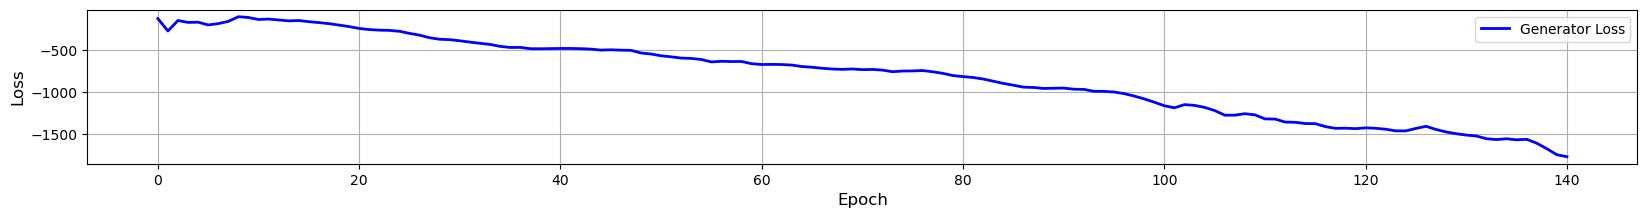

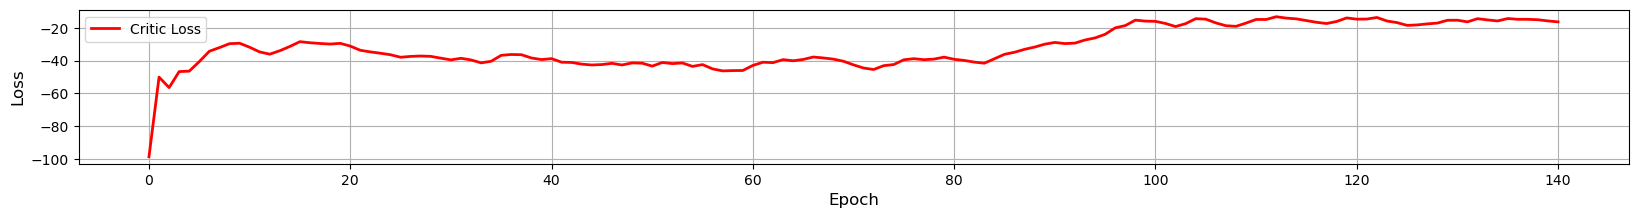

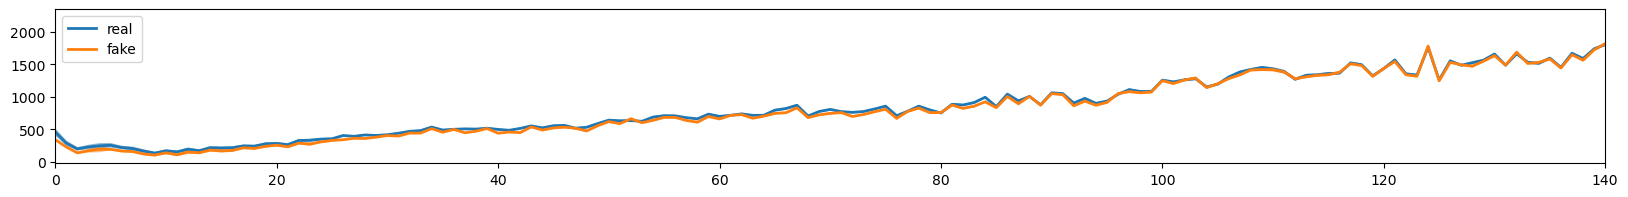

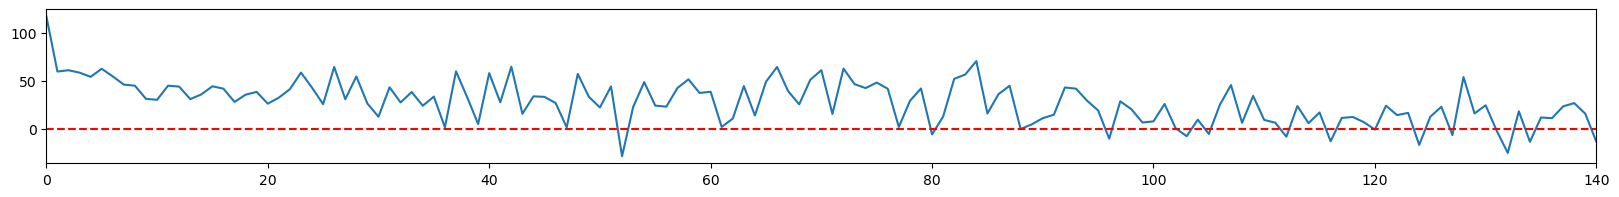

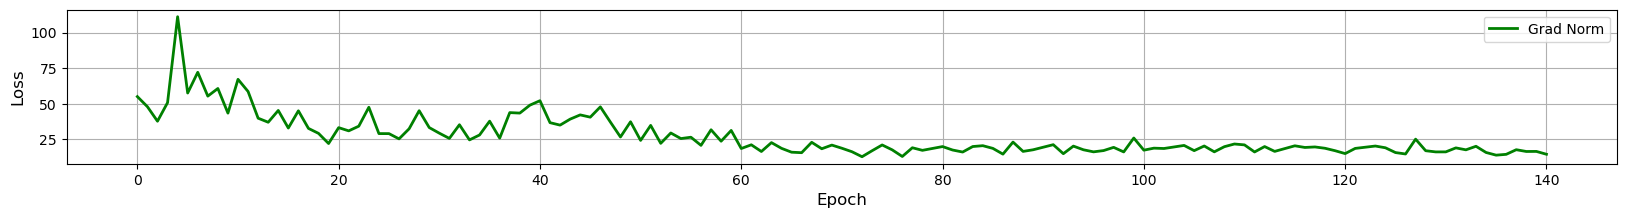

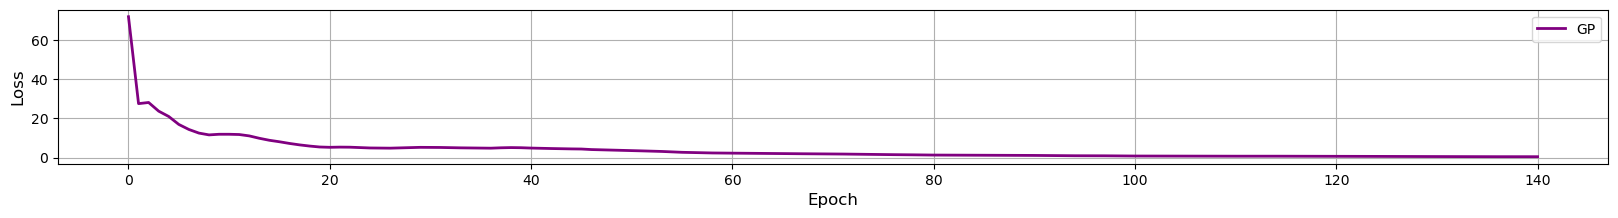

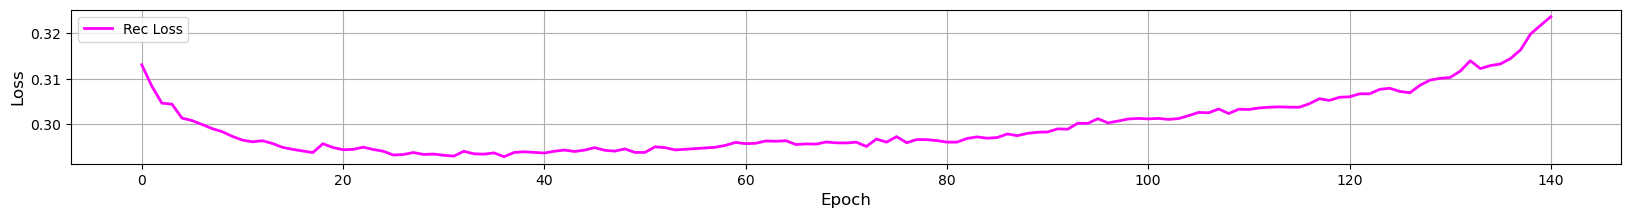

In [16]:
## Stats
import matplotlib.pyplot as plt
import pandas as pd
MODEL_ID = '20260419'
EPOCH = 200
STATS_PATH = f'logs/eo/{MODEL_ID}.csv'

def plot_loss(data, label, color='red'):
    plt.plot(data, label=label, color=color, linestyle='-', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True)
    plt.legend()


ep = 140
bounded = (0, ep)
stats = pd.read_csv(STATS_PATH, index_col=0).reset_index()
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[bounded[0]:bounded[1], '2 g_loss'], label='Generator Loss', color='blue')
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[bounded[0]:bounded[1], '1 d_loss'], label='Critic Loss', color='red')

plt.figure(figsize=(20, 2))
plt.plot(stats.loc[bounded[0]:bounded[1], '5 real_pred'], label='real', linewidth=2)
plt.fill_between(stats.index, stats['5 real_pred'] - stats['7 real_pred_std'], stats['5 real_pred'] + stats['7 real_pred_std'], alpha=0.5)
plt.plot(stats.loc[bounded[0]:bounded[1], '6 fake_pred'], label='fake', linewidth=2)
plt.fill_between(stats.index, stats['6 fake_pred'] - stats['8 fake_pred_std'], stats['6 fake_pred'] + stats['8 fake_pred_std'], alpha=0.5)
plt.legend()
plt.xlim(bounded[0], bounded[1])
limmin = stats.loc[bounded[0]:bounded[1], '6 fake_pred'].min()
limmax = stats.loc[bounded[0]:bounded[1], '6 fake_pred'].max()
# plt.ylim(limmin, limmax)

plt.figure(figsize=(20, 2))
plt.plot(stats['5 real_pred'] - stats['6 fake_pred'])
plt.xlim(bounded[0], bounded[1])
plt.axhline(0, color='red', linestyle='--')
# plt.ylim(-30, 30)

plt.figure(figsize=(20, 2))
plot_loss(stats.loc[:ep, '3 critic_grad_norm'], label='Grad Norm', color='green')
plt.figure(figsize=(20, 2))
plot_loss(stats.loc[:ep, '4 gp'], label='GP', color='purple')

plt.figure(figsize=(20, 2))
plot_loss(stats.loc[:ep, '4b recon_loss'], label='Rec Loss', color='magenta') # 4b recon_loss

# plt.figure(figsize=(20, 2))
# plot_loss(stats.loc[:ep, '9 gen_grad_norm'], label='9 gen_grad_norm', color='orange') # 4b recon_loss

In [5]:
# find at which epoch the recon_loss is minimum
stats['4b recon_loss'].idxmin(), stats['4b recon_loss'].min()

(33, np.float64(0.2991909384727478))

## Repetition check

In [15]:
appraoch = 2
def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1)

if appraoch == 1:
    ## approach 1
    x_gen_reversed = reverse_segmentation(x_gen, N_SUBJECTS)
    blocks = x_gen_reversed.reshape(-1, 512, 8) 
    blocks = (blocks - blocks.mean(axis=(1,2), keepdims=True)) / blocks.std(axis=(1,2), keepdims=True)

    X = blocks.reshape(blocks.shape[0], -1)  #flatten
    corr_gen = np.corrcoef(X)

    # exclude diagonal
    iu = np.triu_indices_from(corr_gen, k=1)
    print(corr_gen[iu].mean())

elif appraoch == 2:
    x_gen_reversed = reverse_segmentation(x_gen, N_SUBJECTS)
    x_mean = x_gen_reversed.mean(0).permute(1, 0)

    # reshape into blocks of 512
    blocks = x_mean.reshape(-1, 512, x_mean.shape[-1])  # [n_blocks, 512, C]

    # compare blocks
    corr = np.corrcoef(blocks.reshape(blocks.shape[0], -1))
    iu = np.triu_indices_from(corr, k=1)
    print(corr[iu].mean())

0.03715885323219621


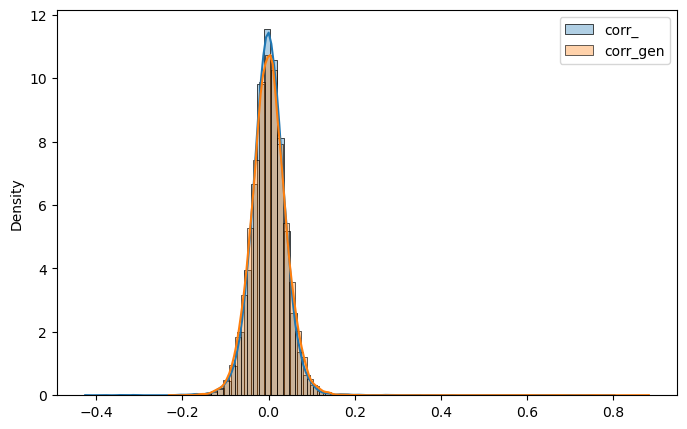

In [ ]:
import seaborn as sns

def sample_for_hist(x, n=15000, seed=0, keep_mean_exact=True):
    x = np.asarray(x).ravel()
    n = min(n, x.size)
    rng = np.random.default_rng(seed)
    y = x[rng.choice(x.size, size=n, replace=False)].astype(float)
    if keep_mean_exact:
        y += (x.mean() - y.mean())   # match original mean exactly
    return np.clip(y, -1, 1)         # correlations

X0 = sample_for_hist(corr_[iu], n=15000, seed=42)
X1 = sample_for_hist(corr_gen[iu], n=15000, seed=43)

plt.figure(figsize=(8,5))
sns.histplot(X0, bins=80, stat="density", kde=True, color="C0", alpha=0.35, label="corr_")
sns.histplot(X1, bins=80, stat="density", kde=True, color="C1", alpha=0.35, label="corr_gen")
plt.legend()
plt.show()

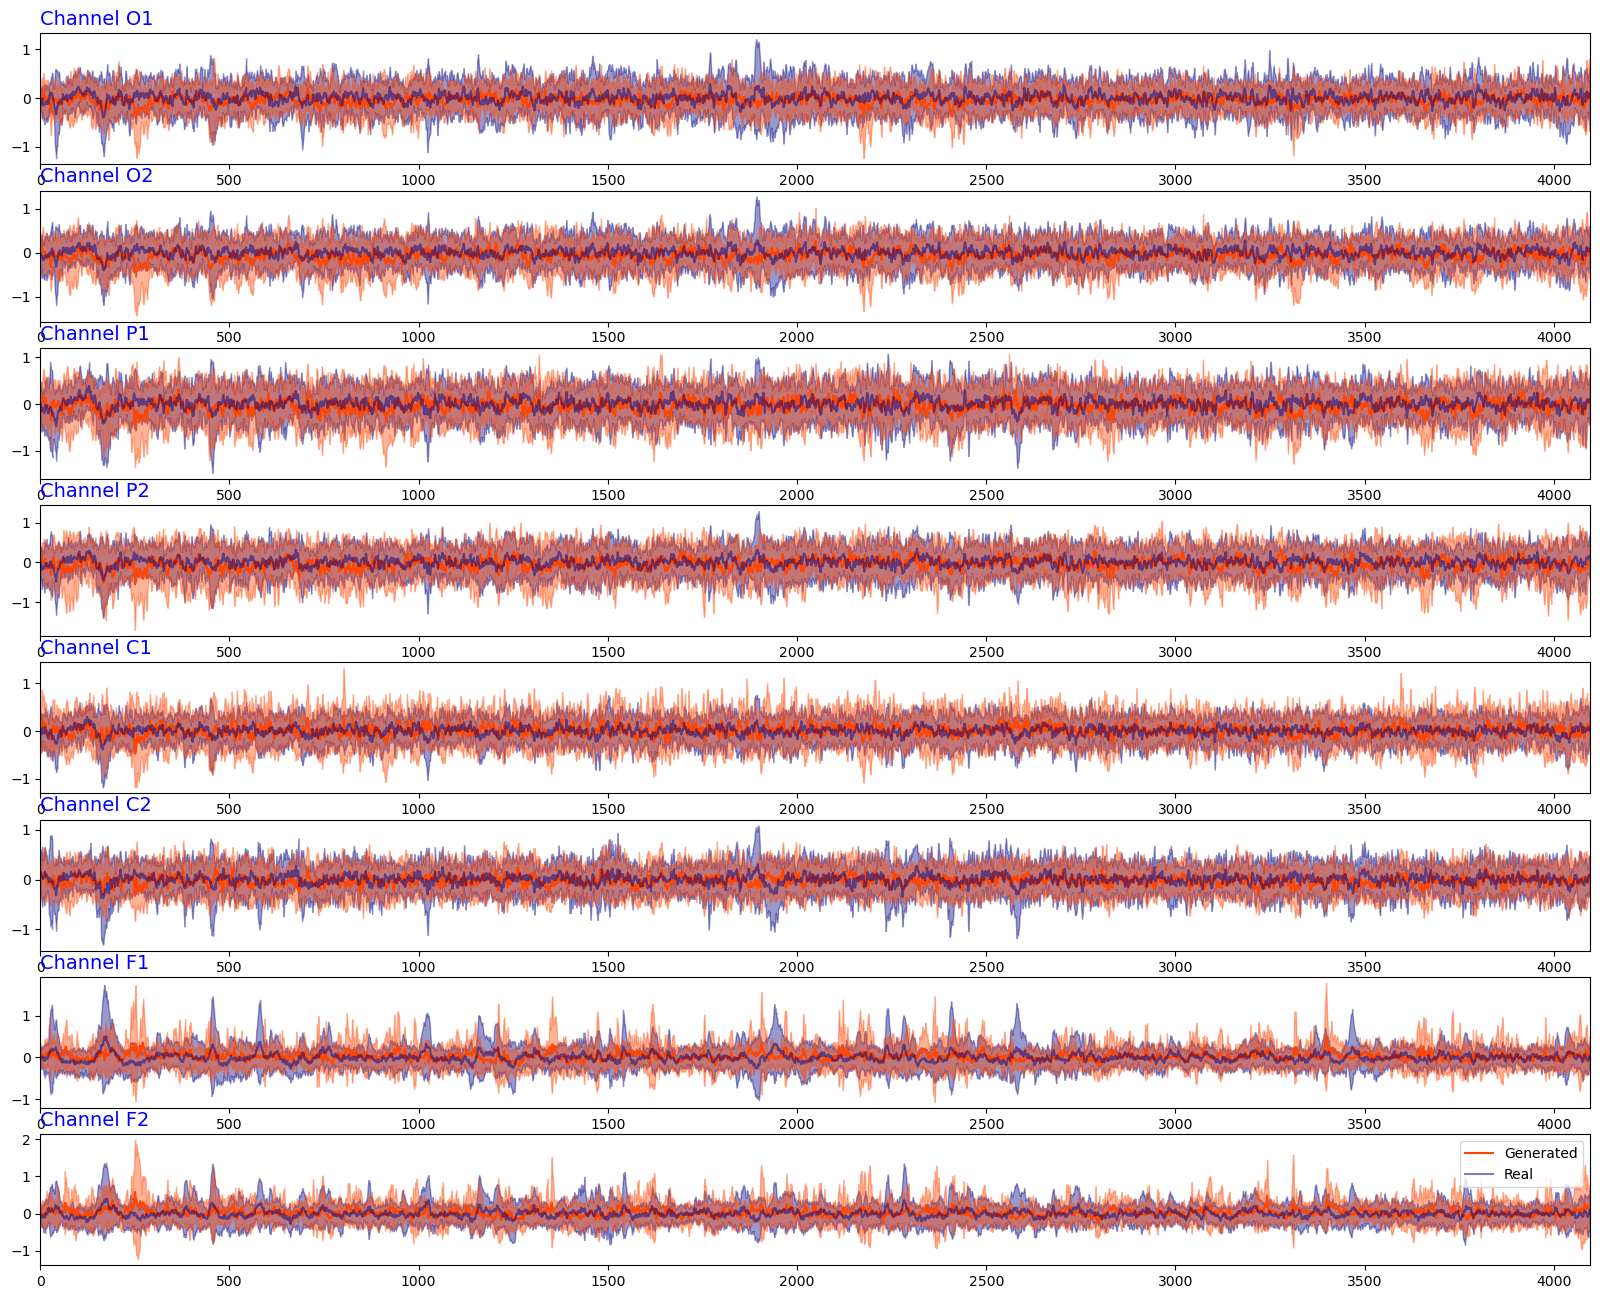

In [6]:
fig, ax = plt.subplots(8, 1, figsize=(20, 16))
for i, ch in enumerate(range(len(CHANNELS))):
        plot_time_domain(reverse_segmentation(x, N_SUBJECTS), reverse_segmentation(x_gen, N_SUBJECTS), 4096, CHANNELS, ax[i], ch)

plt.legend()
plt.show()

## Intermediate layers

In [7]:
@torch.no_grad()
def critic_feature_separation(critic, real_batch, fake_batch, sub_ids, state_ids, feature_dim, eps=1e-8):
    """
    real_batch: (B, T, C) or your input format for critic
    fake_batch: (B, T, C)
    sub_ids:    (B,) long/int
    state_ids:  (B,) long/int
    feature_dim: base C used in critic (the one you called feature_dim)
    Returns:
        per_dim: dict with delta and delta_norm tensors of shape (D_feat,)
        per_block: dict with block-wise scalars
    """

    # 1) Extract features
    # feats_r = critic.call({'x':real_batch, 'sub':sub_ids, 'pos':state_ids})  # (B, D_feat)
    # feats_f = critic.call({'x':fake_batch, 'sub':sub_ids, 'pos':state_ids})  # (B, D_feat)

    feats_r = critic.extract_features(real_batch, sub_ids, state_ids)  # (B, D_feat)
    feats_f = critic.extract_features(fake_batch, sub_ids, state_ids)  # (B, D_feat)

    # Ensure torch tensors
    if not isinstance(feats_r, torch.Tensor):
        feats_r = torch.as_tensor(feats_r)
    if not isinstance(feats_f, torch.Tensor):
        feats_f = torch.as_tensor(feats_f)

    # 2) Per-dimension delta
    delta = (feats_r - feats_f).abs().mean(dim=0)  # (D_feat,)

    # 3) Normalization by variability (per dim)
    std_r = feats_r.std(dim=0, unbiased=False)
    std_f = feats_f.std(dim=0, unbiased=False)
    delta_norm = delta / (std_r + std_f + eps)

    # 4) Block slicing
    C1 = feature_dim
    C2 = 2 * feature_dim
    C3 = 8 * feature_dim
    C4 = 16 * feature_dim

    idx1 = slice(0, C1)
    idx2 = slice(C1, C1 + C2)
    idx3 = slice(C1 + C2, C1 + C2 + C3)
    # idx4 = slice(C1 + C2 + C3, C1 + C2 + C3 + C4)
    # idx5 = slice(C1 + C2 + C3 + C4, -1)

    def block_stats(x, sl):
        return x[sl].mean().item()

    per_block = {
        "h1_delta":      block_stats(delta, idx1),
        "h2_delta":      block_stats(delta, idx2),
        "h3_delta":      block_stats(delta, idx3),
        # "h4_delta":      block_stats(delta, idx4),
        # "h5_delta":      block_stats(delta, idx5),
        "h1_delta_norm": block_stats(delta_norm, idx1),
        "h2_delta_norm": block_stats(delta_norm, idx2),
        "h3_delta_norm": block_stats(delta_norm, idx3),
        # "h4_delta_norm": block_stats(delta_norm, idx4),
        # "h4_delta_norm": block_stats(delta_norm, idx5),
    }

    per_dim = {"delta": delta, "delta_norm": delta_norm}
    return per_dim, per_block, delta, feats_r


In [8]:
b = 1200
critic = model.critic
per_dim, per_block, delta, f_r = critic_feature_separation(
    critic=critic,
    real_batch=x[:b].float().to('mps'),
    fake_batch=x_gen[:b].float().to('mps'),
    sub_ids=sub[:b].to('mps'),
    state_ids=state[:b].to('mps'),
    feature_dim=8,
)

print(per_block)

{'h1_delta': 0.000257885578321293, 'h2_delta': 0.00020110320474486798, 'h3_delta': 0.00017823520465753973, 'h1_delta_norm': 0.14877739548683167, 'h2_delta_norm': 0.2002909630537033, 'h3_delta_norm': 0.21653711795806885}


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


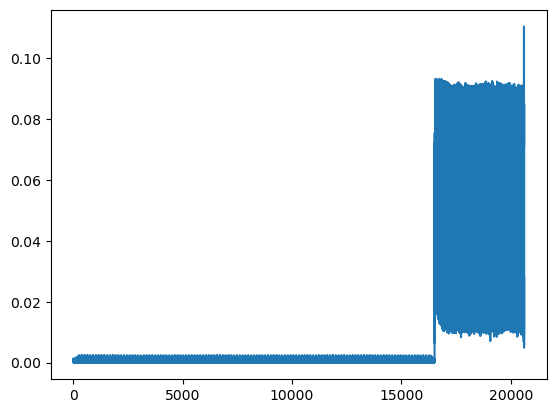

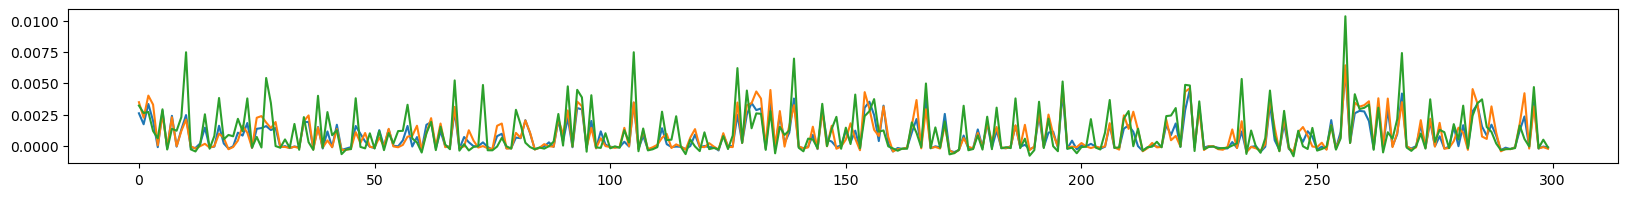

In [9]:
critic = model.critic
critic.eval()
critic.output_features = True

out = critic.predict({'x':x[:128+32], 'sub':sub[:128+32], 'pos':state[:128+32]})
plt.plot(out.std(0))

plt.figure(figsize=(20, 2))
plt.plot(out[00, :300])
plt.plot(out[20, :300])
plt.plot(out[30, :300])

In [10]:
critic = model.critic
bs = 1200
with torch.no_grad():
    critic.output_features = True
    z = critic.predict({'x': x[:bs], 'sub': sub[:bs], 'pos': state[:bs]})  # (B, D)
    critic.output_features = False

    var = torch.tensor(z.var(axis=0))           # (D,)
    topk = torch.topk(var, k=50).values
    print("median var:", var.median().item(), "top-50 mean var:", topk.mean().item())

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
median var: 3.7235577110550366e-07 top-50 mean var: 0.0042517175897955894


In [11]:
u, s, v = torch.pca_lowrank(torch.tensor(z), q=20)
print("top singular values:", s)

top singular values: tensor([63.9003, 45.2276, 30.7381, 25.5543, 12.5266,  6.2131,  6.0481,  5.9267,
         5.6485,  5.4113,  5.1564,  4.8289,  4.5058,  4.3019,  4.1319,  3.9525,
         3.7936,  3.6974,  3.5670,  3.1793])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


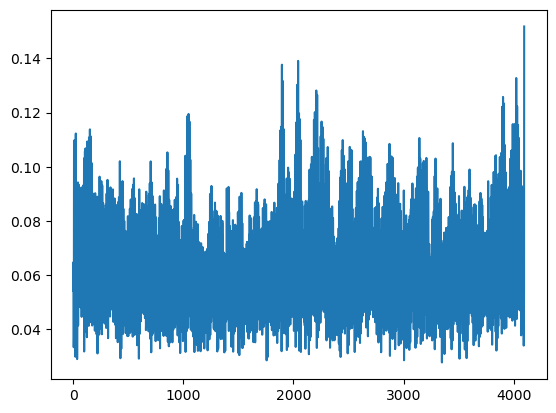

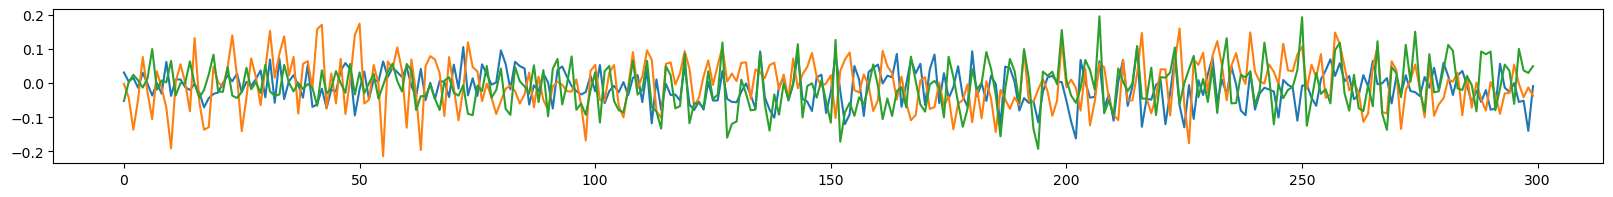

In [12]:
from keras import ops, layers
inputs = keras.Input(shape=(512, 8))
# sub_emb = critic.layers[0](sub.view(-1))
# sub_emb = critic.layers[1](x, sub_emb)
x_hp = critic.layers[3](inputs)
x_cat = ops.concatenate([inputs, x_hp], axis=-1)
h1 = critic.layers[4](x_cat)
h = layers.Flatten()(h1)
# out = ops.concatenate([h, h1], axis=-1)

# sub_emb = critic.layers[0](sub[128:128+32].to('mps').view(-1))
# state_emb = critic.layers[1](state_ids[128:128+32].to('mps'))
# x_ = critic.layers[3](x[128:128+32].float().to('mps'), sub_emb)

extractor = keras.Model(inputs, h)
out = extractor.predict(x[128:128+32].float().to('mps'))
plt.plot(out.std(0))

plt.figure(figsize=(20, 2))
plt.plot(out[00, :300])
plt.plot(out[20, :300])
plt.plot(out[30, :300])

### Critic Real vs. Fake Speratability

In [14]:
# from src.EEGModalNet.models.FiLMGAN import FiLMGAN
# CHECKPOINTS_PATH = 'logs/eo/20260224_vepoch_160.model.keras'
# model = keras.saving.load_model(CHECKPOINTS_PATH, custom_objects={'FiLMGAN': FiLMGAN}, compile=False)
# with torch.no_grad():
#      x_gen = generate_data(model, x, sub, state, N_SUBJECTS, latent_dim=LATENT_DIM, use_random_sub=False).cpu()

rndidx = torch.randperm(x[:bs].shape[0])
critic = model.critic
critic.eval()
critic.output_features = True

z_real = torch.tensor(critic.predict({'x': x[:bs].float().to('mps'),
                    'sub': sub[:bs].to('mps'),
                    'pos': state[:bs].to('mps')}))
z_fake = torch.tensor(critic.predict({'x': x_gen[:bs].float().to('mps'),
                    'sub': sub[:bs][rndidx].to('mps'),
                    'pos': state[:bs][rndidx].to('mps')}))

dist = (z_real.mean(0) - z_fake.mean(0)).norm().item()
print("ciritc separability:", dist / ((z_real.norm(dim=1).mean().item() + z_fake.norm(dim=1).mean().item()) / 2) * 100)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
ciritc separability: 3.0451484529150257


### Correlation between intermediate layers and the output 

In [ ]:
# critic = model.critic
# critic.eval()
# critic.trainable = False
# critic.output_features = False

# with torch.no_grad():
#     out, z = critic({'x': x.float().to('mps'),
#                      'sub': sub.to('mps'),
#                      'pos': state.to('mps')})

#     zn = z.norm(dim=1)
#     zn_centered = zn - zn.mean()
#     out_centered = out - out.mean()

#     corr = (zn_centered * out_centered).mean() / (
#     zn_centered.std() * out_centered.std() + 1e-8
#     )

#     # corr = torch.corrcoef(torch.stack([zn, out.squeeze()]))[0,1].item()

#     print("corr(||feat||, out):", corr)

## Quality of the Generated Data

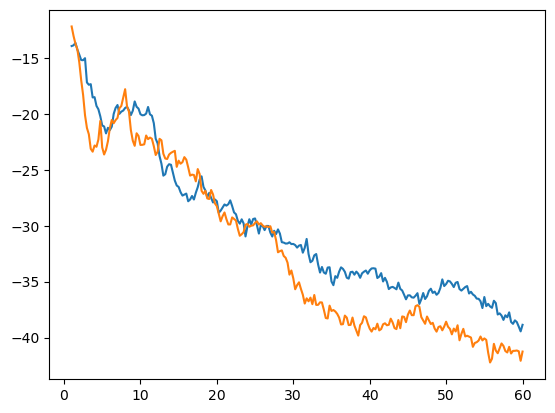

In [16]:
# x_gen_reversed.shape
x_reversed = reverse_segmentation(x, N_SUBJECTS).cpu().detach()
s = 2

psd, freqs = mne.time_frequency.psd_array_welch(x_gen_reversed[s].numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
psd_real, freqs = mne.time_frequency.psd_array_welch(x_reversed[s].numpy(), sfreq=128, fmin=1, fmax=60, n_fft=512, verbose=False)
psd = 10*np.log10(psd)
psd_real = 10*np.log10(psd_real)

ch = 0
plt.plot(freqs, psd[ch])
plt.plot(freqs, psd_real[ch])

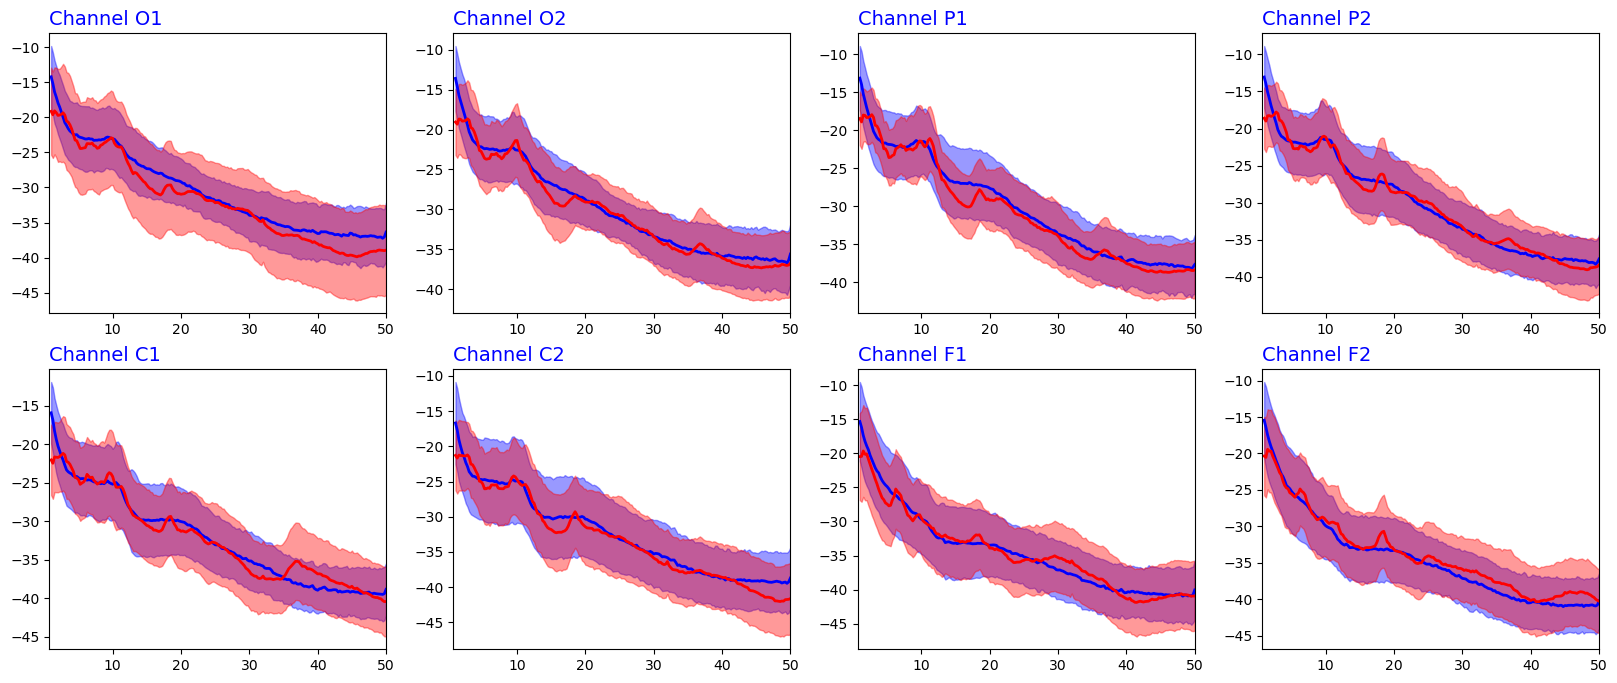

In [17]:
def reverse_segmentation(x, n_subjects):
    return x.unflatten(0, (n_subjects, -1)).flatten(1, 2).permute(0, 2, 1).cpu().detach()

x_gen_reversed = reverse_segmentation(x_gen, N_SUBJECTS)
x_reversed = reverse_segmentation(x, N_SUBJECTS)

def plot_psd_multi_channel(x, channels, ax, n_subjects=202, fmin=1, fmax=50, n_fft=512, label='real', db=True, color='blue',
                           reverse_first=True):
    psd, freq = mne.time_frequency.psd_array_welch(x.numpy(), sfreq=128, fmin=fmin, fmax=fmax, n_fft=n_fft, verbose=False)
    if db:
        psd = 10*np.log10(psd)
    for i, c in enumerate(range(len(channels))):
        psd_ = psd[:, c, :]
        ax[i//4, i%4].plot(freq, psd_.mean(0), label=label, linewidth=2, color=color)
        ax[i//4, i%4].fill_between(freq, psd_.mean(0) - psd_.std(0), psd_.mean(0) + psd_.std(0), alpha=0.4, color=color)
        ax[i//4, i%4].set_title(f'Channel {channels[c]}', color='blue', fontsize=14, loc='left')
        ax[i//4, i%4].set_xlim([0.7, fmax])

channels = CHANNELS

_, ax = plt.subplots(2, 4, figsize=(20, 8))
plot_psd_multi_channel(x_reversed, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True)
plot_psd_multi_channel(x_gen_reversed, CHANNELS, ax, n_subjects=N_SUBJECTS, reverse_first=True, color='red')

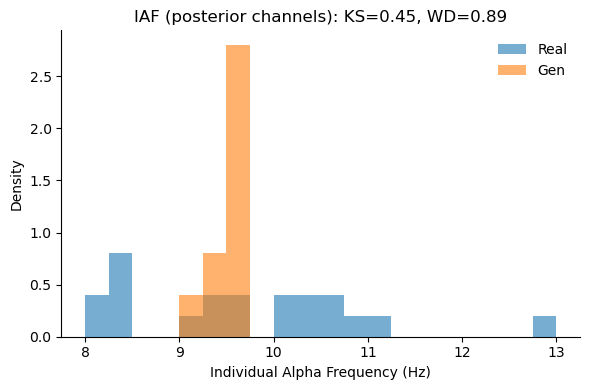

Real IAF: median=9.50 Hz, IQR=(8.25, 10.31)
Gen  IAF: median=9.50 Hz, IQR=(9.25, 9.50)
KS=0.450, WD=0.888


In [9]:
psd_real, psd_fake, freqs = calculate_psd_different_methods(x, x_gen, N_SUBJECTS, psd_method='reverse_first')
# psd_real = psd_real[n_subject:]
# psd_fake = psd_fake[n_subject:]
from scipy.signal import savgol_filter
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def compute_iaf(psd, freqs, posterior_ch_idx=(0, 1, 2, 3), fmin=8.0, fmax=13.0):
    """Return IAF (Hz) per subject using posterior-average log-PSD peak."""
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    f_band = freqs[band_mask]
    n_subj = psd.shape[0]
    iaf = np.full(n_subj, np.nan)

    # Savitzky–Golay smoothing window (odd, ~1/10 of band points, >=5)
    w = max(5, (len(f_band) // 10) | 1)  # make odd
    for s in range(n_subj):
        p = psd[s, posterior_ch_idx].mean(axis=0)           # average posterior
        lp = np.log(np.clip(p, 1e-12, None))                # log-PSD
        lp_band = lp[band_mask]
        lp_smooth = savgol_filter(lp_band, window_length=w, polyorder=3, mode='interp')
        peak_idx = np.argmax(lp_smooth)
        iaf[s] = f_band[peak_idx]
    return iaf

def iaf_analysis(psd_real, psd_gen, freqs, posterior_ch_idx, fmin=8.0, fmax=13.0, bins=20):
    iaf_r = compute_iaf(psd_real, freqs, posterior_ch_idx, fmin, fmax)
    iaf_g = compute_iaf(psd_gen,  freqs, posterior_ch_idx, fmin, fmax)

    # Drop NaNs if any
    mask = ~np.isnan(iaf_r)
    iaf_r = iaf_r[mask]
    mask = ~np.isnan(iaf_g)
    iaf_g = iaf_g[mask]

    # Statistics
    ks = ks_2samp(iaf_r, iaf_g).statistic
    wd = wasserstein_distance(iaf_r, iaf_g)

    # Plot
    lo, hi = float(min(iaf_r.min(), iaf_g.min())), float(max(iaf_r.max(), iaf_g.max()))
    plt.figure(figsize=(6,4))
    plt.hist(iaf_r, bins=bins, range=(lo,hi), alpha=0.6, density=True, label='Real')
    plt.hist(iaf_g, bins=bins, range=(lo,hi), alpha=0.6, density=True, label='Gen')
    plt.xlabel('Individual Alpha Frequency (Hz)')
    plt.ylabel('Density')
    plt.title(f'IAF (posterior channels): KS={ks:.02f}, WD={wd:.02f}')
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # Optional: print summary numbers for the paper
    def med_iqr(x):
        q1, med, q3 = np.percentile(x, [25, 50, 75])
        return med, (q1, q3)
    med_r, iqr_r = med_iqr(iaf_r)
    med_g, iqr_g = med_iqr(iaf_g)
    print(f"Real IAF: median={med_r:.2f} Hz, IQR=({iqr_r[0]:.2f}, {iqr_r[1]:.2f})")
    print(f"Gen  IAF: median={med_g:.2f} Hz, IQR=({iqr_g[0]:.2f}, {iqr_g[1]:.2f})")
    print(f"KS={ks:.3f}, WD={wd:.3f}")
    return iaf_r, iaf_g

#---- usage example ----
iaf_r, iaf_g = iaf_analysis(psd_real, psd_fake, freqs, posterior_ch_idx=(0, 1, 2, 3))

## Critic Performance

In [ ]:
critic = model.critic

rndidx = torch.randperm(x.shape[0])

with torch.no_grad():
    real_pred = critic.predict(data)
    fake_pred = critic.predict({'x': x_gen.float().to('mps'), 'sub': sub[rndidx].to('mps'), 'pos': state[rndidx].to('mps')})

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


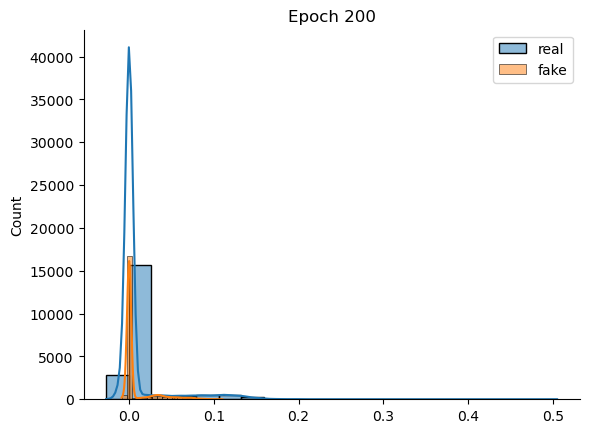

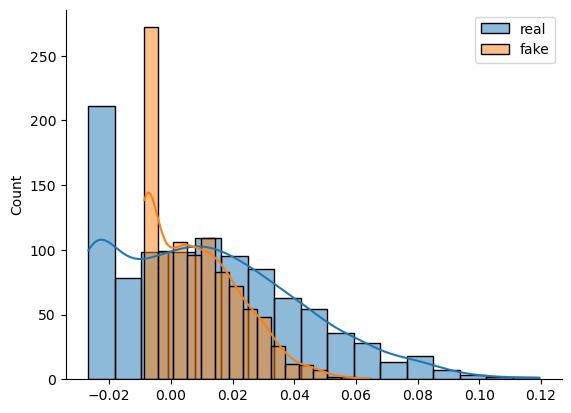

In [16]:
fake_scores = fake_pred[0].flatten()
real_scores = real_pred[0].flatten()
import seaborn as sns

sns.histplot(real_scores, bins=20, alpha=0.5, label='real', kde=True)
sns.histplot(fake_scores, bins=20, alpha=0.5, label='fake', kde=True)
plt.legend()
plt.title(f'Epoch {EPOCH}')
plt.show()

# plot a normal distribution using the mean and std and min and max values of the critic scores
f_scores = np.random.normal(fake_scores.mean(), fake_scores.std(), 1000)
r_scores = np.random.normal(real_scores.mean(), real_scores.std(), 1000)

# Clip the generated scores to the min and max values of the real and fake scores
r_scores = np.clip(r_scores, real_scores.min(), real_scores.max())
f_scores = np.clip(f_scores, fake_scores.min(), fake_scores.max())

sns.histplot(r_scores, label='real', kde=True)
sns.histplot(f_scores, label='fake', kde=True)
plt.legend()

# train a classifier on the real and generated features

In [29]:
from sklearn.metrics import roc_auc_score
critic = model.critic
critic.eval()
critic.output_features = True
bs = 1200

z_real = torch.tensor(critic.predict({'x': x[:bs].float().to('mps'), 'sub': sub[:bs].to('mps'), 'pos': state[:bs].to('mps')}))
z_fake = torch.tensor(critic.predict({'x': x_gen[:bs].float().to('mps'), 'sub': sub[:bs].to('mps'), 'pos': state[:bs].to('mps')}))

X = torch.cat([z_real, z_fake], dim=0)        # (2B, 12352)
y = torch.cat([
    torch.ones(z_real.size(0)),
    torch.zeros(z_fake.size(0))
], dim=0)

# break old graph
X = X.float().cpu().detach()
y = y.float().cpu().detach()

perm = torch.randperm(X.size(0), device=X.device)
X = X[perm]
y = y[perm]

split = int(0.8 * X.size(0))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = (X_train - X_train.mean()) / X_train.std()
X_test = (X_test - X_test.mean()) / X_test.std()  # use train stats for test normalization

clf = torch.nn.Linear(X.shape[1], 1).to(X.device)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)
loss_fn = torch.nn.BCEWithLogitsLoss()

for _ in range(200):
    logits = clf(X_train).squeeze(-1)
    loss = loss_fn(logits, y_train.float())  # BCE expects float targets
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


with torch.no_grad():
    logits = clf(X_test).squeeze()
    probs = torch.sigmoid(logits)
    auc = roc_auc_score(y_test.numpy(), probs.numpy())

print("C2ST AUC test:", auc)

with torch.no_grad():
    logits = clf(X_train).squeeze()
    probs = torch.sigmoid(logits)
    auc = roc_auc_score(y_train.numpy(), probs.numpy())
print("C2ST AUC train:", auc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
C2ST AUC test: 0.6973769063180828
C2ST AUC train: 0.8446756206756206


# CLASSIFICATION

## setup

In [ ]:
## Classification
from typing import List
from keras.layers import MaxPooling1D, Flatten, Concatenate
from keras import Model, layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split 
from src.EEGModalNet.preprocessing.preprocessing import preprocess_data
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import hashlib

# Constants
EEG_DATA_PATH = 'data/LEMON_DATA/EO-EC_processed_ch-16_sf-128.nc5'
DEMOGRAPHICS_PATH = 'logs/age_group_classifier/Demographics.csv'
CLS_CHECKPOINT_PATH = 'logs/'


def extract_features(critic, X_input, subj_emb, state_ids, groups, EXTRACTION_MODE='intermediate', bs=208):
    """
    EXTRACTION_MODE 'final', 'intermediate', 'flatten', or 'cbra'
    """
    critic.trainable = False 

    if EXTRACTION_MODE == 'intermediate':
        feats = []
        n_batchs = X_input.shape[0] // bs

        for batch in range(n_batchs):
            start = batch * bs
            end = (batch + 1) * bs

            with torch.no_grad():
                feat = critic.extract_features(
                        X_input[start:end].float().to('mps'),
                        subj_emb[start:end].to('mps'),
                        state_ids[start:end].to('mps')
                        )
                
            feats.append(feat.cpu())

        feats = torch.tensor(np.array(feats)).flatten(0, 1)

    elif EXTRACTION_MODE == 'final':
        #turn on feature mode
        critic.output_features = True
        pos = torch.randn((X_input.shape[0], 8, 2))
        feats = critic.predict(
            {'x': X_input, 'sub': groups, 'pos': state_ids, 'e_mean': subj_emb},
            batch_size=256,
            verbose=1,
        )

        critic.output_features = False    # restore normal behaviour
    elif EXTRACTION_MODE == 'flatten':
        feats = X_input.reshape(X_input.shape[0], -1)
    
    elif EXTRACTION_MODE == 'cbra':  # TODO: verify
        
        feats = X_e
    
    else:
            raise ValueError(f'Unknown EXTRACTION_MODE: {EXTRACTION_MODE}')
    return feats

def extract_features_batched(critic, X_input, subj_emb, state_ids, batch_size=256, device='cpu'):
    """
    Extract features in batches to avoid memory overflow.
    
    Args:
        critic: The critic model
        X_input: Input tensor (N, T, C)
        subj_emb: Subject embeddings (N, D)
        state_ids: State IDs (N,)
        batch_size: Number of samples per batch
        device: Device to process on
    
    Returns:
        Concatenated features as numpy array
    """
    all_h1 = []
    all_h = []
    n_samples = X_input.shape[0]
    
    for i in range(0, n_samples, batch_size):
        end_idx = min(i + batch_size, n_samples)
        batch_inputs = {
            'x': X_input[i:end_idx].float().to(device),
            'sub': subj_emb[i:end_idx].to(device),
            'pos': state_ids[i:end_idx].to(device)
        }
        h1_batch, h_batch = critic.encode_features(batch_inputs)
        all_h1.append(h1_batch.cpu().detach())
        all_h.append(h_batch.cpu().detach())
    
    h1_full = torch.cat(all_h1, dim=0)
    h_full = torch.cat(all_h, dim=0)
    feats = torch.cat([h1_full.mean(1), h_full.mean(1)], dim=-1).numpy()
    
    return feats, h1_full, h_full


def extract_features_adaptive_pool(critic, X_input, subj_emb, state_ids, pool_size=4, batch_size=256, device='mps'):
    """
    Adaptive pooling: Convert temporal dimension to fixed size.
    This preserves spatial information better than mean pooling.
    """
    all_h1 = []
    all_h = []
    n_samples = X_input.shape[0]
    
    for i in range(0, n_samples, batch_size):
        end_idx = min(i + batch_size, n_samples)
        batch_inputs = {
            'x': X_input[i:end_idx].float().to(device),
            'sub': subj_emb[i:end_idx].to(device),
            'pos': state_ids[i:end_idx].to(device)
        }
        
        h1_batch, h_batch = critic.encode_features(batch_inputs)
        all_h1.append(h1_batch.cpu().detach())
        all_h.append(h_batch.cpu().detach())
    
    h1_full = torch.cat(all_h1, dim=0)  # (N, T1, C1)
    h_full = torch.cat(all_h, dim=0)    # (N, T2, C2)
    
    # Adaptive pooling to (N, pool_size, C)
    h1_pooled = F.adaptive_avg_pool1d(h1_full.transpose(1, 2), pool_size)  # (N, C1, pool_size)
    h_pooled = F.adaptive_avg_pool1d(h_full.transpose(1, 2), pool_size)    # (N, C2, pool_size)
    
    # Flatten: (N, C1*pool_size + C2*pool_size)
    feats = torch.cat([h1_pooled.flatten(1), h_pooled.flatten(1)], dim=-1).numpy()
    
    return feats


def extract_features_batched_deterministic(
    critic, X_input, subj_emb, state_ids, 
    batch_size=256, device='cpu', seed=42
):
    """
    Extract features in batches with full determinism control.
    """
    # Set all random seeds BEFORE computation
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    
    # Ensure deterministic algorithms
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Ensure critic is truly in eval mode and frozen
    critic.eval()
    for param in critic.parameters():
        param.requires_grad = False
    
    # Disable any dropout/batch norm randomness
    for module in critic.modules():
        if hasattr(module, 'training'):
            module.train(False)
    
    all_h1 = []
    all_h = []
    n_samples = X_input.shape[0]
    
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            batch_inputs = {
                'x': X_input[i:end_idx].float().to(device),
                'sub': subj_emb[i:end_idx].to(device),
                'pos': state_ids[i:end_idx].to(device)
            }
            h1_batch, h_batch = critic.encode_features(batch_inputs)
            all_h1.append(h1_batch.cpu().detach())
            all_h.append(h_batch.cpu().detach())
    
    h1_full = torch.cat(all_h1, dim=0)
    h_full = torch.cat(all_h, dim=0)
    feats = torch.cat([h1_full.mean(1), h_full.mean(1)], dim=-1).numpy()
    
    # Compute checksum for verification
    checksum = float(np.sum(feats))
    checksum_hash = hashlib.md5(feats.tobytes()).hexdigest()
    
    print(f"Checksum (sum): {checksum}")
    print(f"Checksum (hash): {checksum_hash}")
    
    return feats, h1_full, h_full


def plot_some_features(out):
    plt.figure(figsize=(20, 2))

    if out.ndim == 3:
        plt.plot(out[000, :, 0])
        plt.plot(out[100, :, 0])
        plt.plot(out[150, :, 0])
    else:
        plt.plot(out[000, :100])
        plt.plot(out[100, :100])
        plt.plot(out[150, :100])

## otka data

In [4]:
TASK = 'gender'
DO_DOWN_SAMPLE = True
DATA_TO_BE_USED = 'OTKA'
REORDERING = False

if DATA_TO_BE_USED == 'OTKA':
    ## Train classifier on OTKA dataset
    # eeg data is experience data that is downsampled to 128Hz and Robustly scaled
    EEG = xr.open_dataarray('data/OTKA/experiment_EEG_data.nc5', engine='h5netcdf')
    # exclude_sub_ids = 'sub-52'
    # EEG = EEG.sel(subject=~EEG.subject.isin(exclude_sub_ids))
    behavioral = pd.read_csv('data/OTKA/PLB_HYP_data_MASTER.csv')
    if TASK == 'gender':
        classes = behavioral[['gender', 'bids_id']].dropna().set_index('bids_id')
        classes['gender'] = classes['gender'].apply(lambda x: 0 if x == 'Male' else 1)
        # classes = classes.query('bids_id != 52')
    if TASK == 'hypno':
        classes = behavioral[['hypnotizability_total', 'bids_id']].dropna().set_index('bids_id')
        classes['hypnotizability_total'] = classes['hypnotizability_total'].apply(lambda x: 1 if x > 5 else 0)

    def format_subject_id(subject_id):
        return f"sub-{int(subject_id):02d}"

    sub_ids = classes.index
    if DO_DOWN_SAMPLE:
        n_y0 = (classes == 0).sum().values
        n_y1 = (classes == 1).sum().values
        n_min = min(n_y0, n_y1)
        n_subjects = n_min * 2
        if TASK == 'gender':
            y0_sub_ids = classes.query("gender == 0").index[:n_min[0]]
            y1_sub_ids = classes.query("gender == 1").index[:n_min[0]]
        if TASK == 'hypno':
            y0_sub_ids = classes.query("hypnotizability_total == 0").index[:n_min[0]]
            y1_sub_ids = classes.query("hypnotizability_total == 1").index[:n_min[0]]
        sub_ids = y1_sub_ids.append(y0_sub_ids)

    sub_ids_formatted = [format_subject_id(sub_id) for sub_id in sub_ids]

    # X_input
    x = EEG.sel(subject=sub_ids_formatted, channel=CHANNELS).to_numpy()
    x = x.reshape(-1, *x.shape[2:])

    # remove those two missing recordings from the last participants if it's among the sub ids
    if 52 in sub_ids:
        x = np.concatenate([x[:-3], x[-1:]])

    # Process
    x = preprocess_data(x, sampling_rate=128)

    # Highpass filter
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

    # Remove the line noise
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

    X_input = torch.tensor(x.copy()).unfold(2, TIME_DIM, TIME_DIM).permute(0, 2, 3, 1).flatten(0, 1)

    # Classes
    n_subjects = len(sub_ids)
    y = classes.loc[sub_ids].values
    # if REORDERING:
    #     y = y[reordering_idx]
    y = y.repeat(416)  # X_input.shape[0] // n_subjects

    # Groups
    sub = torch.tensor(np.arange(0, n_subjects).repeat(416)[:, np.newaxis])
    groups = sub.squeeze().numpy()

    # remove extra data from those two missing sessions
    y = y[:-208]
    groups = groups[:-208]

    print(y.mean())

else:
    print(f'using DS data and task is {TASK}')
    EEG = xr.open_dataarray('data/ds005385/ds005385.nc5', engine='h5netcdf')
    demo = pd.read_csv('data/ds005385/demographic.csv')
    demo = demo.set_index('participant_id')

    REORDERING = False

    if TASK == 'gender':
        classes = demo['sex'].apply(lambda x: 0 if x == 'F' else 1)
    elif TASK == 'age':
        classes = demo['age_group'].apply(lambda x: 0 if x == 'young' else 1)

    sub_ids = classes.index  #TODO: this will rewrite the sub_id from above, should be fixed
    if DO_DOWN_SAMPLE:
        print('balancing the classes')
        n_y0 = (classes == 0).sum()
        n_y1 = (classes == 1).sum()
        n_min = int(min(n_y0, n_y1))
        n_subjects = n_min * 2
        y0_sub_ids = classes[classes == 0].index[:n_min]
        y1_sub_ids = classes[classes == 1].index[:n_min]
        sub_ids = y0_sub_ids.append(y1_sub_ids)


    # X_input
    x = EEG.sel(subject=sub_ids, channel=CHANNELS).to_numpy()

    # Process
    x = preprocess_data(x, sampling_rate=128)

    # Highpass filter
    sos = butter(4, 0.5, btype='high', fs=128, output='sos')
    x = sosfiltfilt(sos, x, axis=-1)

    # Remove the line noise
    x, _ = dss.dss_line(x.T, fline=50, sfreq=128, nremove=1)
    x = x.T

    if REORDERING:
        reordering_idx = torch.randperm(x.shape[0])
        x = x[reordering_idx]

    X_input = torch.tensor(x.copy()).unfold(2, TIME_DIM, TIME_DIM).permute(0, 2, 3, 1).flatten(0, 1)

    # Classes
    n_subjects = len(sub_ids)
    y = classes.loc[sub_ids].values
    if REORDERING:
        y = y[reordering_idx]
    y = y.repeat(X_input.shape[0] / n_subjects)

    # Groups
    sub = torch.tensor(np.arange(0, n_subjects).repeat(X_input.shape[0] // n_subjects)[:, np.newaxis]) 
    groups = sub.squeeze().numpy()

>>>>Corrected Mean: -0.10447078122481923, Std: 1.3249299943650776, Max: 19.57722445510527, Min: -16.626952643822857
>>>>Scaled Mean: 0.017158769586976073, Std: 1.2618481266532553, Max: 62.81975200938929, Min: -53.354775763964824
>>>>Normalized Mean: 5.35854250196154e-17, Std: 0.9999999999999998, Max: 18.9851607974706, Min: -17.66132210232329
>>>>Clamped Mean: 5.35854250196154e-17, Std: 0.9999999999999998, Max: 18.9851607974706, Min: -17.66132210232329
Power of components removed by DSS: 0.10
0.5098039215686274


## Classifier

In [ ]:
device = "cpu"

CHECKPOINTS_PATH = "logs/eo/20260419_epoch_40.model.keras"

model = keras.saving.load_model(
    CHECKPOINTS_PATH,
    custom_objects={"FiLMGAN": FiLMGAN},
    compile=False,
)
critic = model.critic
critic.eval()
critic.to(device)

for p in critic.parameters():
    p.requires_grad = False

# Force-build the Keras conv layers on the SAME device
dummy = {
    "x": torch.zeros((1, critic.time_dim, critic.feature_dim), dtype=torch.float32, device=device),
    "sub": torch.zeros((1, critic.d_sub), dtype=torch.float32, device=device),
    "pos": torch.zeros((1, 1), dtype=torch.long, device=device),
}
with torch.no_grad():
    _ = critic.encode_features(dummy)

# Reload checkpoint weights after build
model.load_weights(CHECKPOINTS_PATH)

# Keep all feature inputs on the SAME device
e_mean = critic.sub_emb.module.weight.mean(0).detach().to(device)
B = X_input.shape[0]
subj_emb = e_mean[None, :].repeat(B, 1)
state_ids = torch.zeros((B, 1), dtype=torch.long, device=device)

feats, _, _ = extract_features_batched_deterministic(
    critic,
    X_input.to(device),
    subj_emb,
    state_ids,
    batch_size=256,
    device=device,
)

Checksum (sum): 120702.3515625
Checksum (hash): cff1f1a77bf645f2dcd1adc70dd34ee2


In [ ]:
scale = True
split_method = 'group_shuffle' # 'stratified' or 'group_shuffle'
rnds = 8

if split_method == 'group_shuffle':
    group_shuffle = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=rnds)
    train_idx, val_idx = next(group_shuffle.split(X_input, y, groups=groups))
elif split_method == 'stratified':
    train_idx, val_idx = train_test_split(np.arange(X_input.shape[0]), test_size=0.3, random_state=rnds, stratify=y)
else:
    raise ValueError(f'Unknown split method: {split_method}')


print(y[train_idx].mean(), y[val_idx].mean())

if scale:
    scaler = StandardScaler().fit(feats)
    feats_train = scaler.transform(feats[train_idx])
    feats_val = scaler.transform(feats[val_idx])

else:
    feats_train = feats[train_idx]
    feats_val = feats[val_idx]

plot_some_features(feats_train)
print("Features mean", feats.mean(), "std:", feats.std()) 
print("Feature train mean:", feats_train.mean(), "std:", feats_train.std())
print("Feature val mean:", feats_val.mean(), "std:", feats_val.std())

In [ ]:
os.environ['PYTHONHASHSEED'] = '0'
np.random.seed(42)
torch.manual_seed(42)
torch.mps.manual_seed(42)
keras.utils.set_random_seed(42)

cls_model = keras.models.Sequential([
    layers.Dense(1, activation='sigmoid')
])

cls_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy")
    ]
    )

cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y[train_idx]),
    y=y[train_idx]
)
class_weights = dict(zip(np.unique(y[train_idx]), cw))

history = cls_model.fit(
    feats_train, y[train_idx],
    epochs=200,
    batch_size=2048,
    validation_data=(feats_val, y[val_idx]),
    class_weight=class_weights,
    shuffle=False
)

In [ ]:
SMOOTHED = False
fig, ax = plt.subplots(2, 2, figsize=(20, 5))
i = 1000

# Apply rolling mean for smoother visualization
window_size = 0
if SMOOTHED:
    val_accuracy_smoothed = pd.Series(history.history['val_accuracy']).rolling(window=window_size).mean()
    accuracy_smoothed = pd.Series(history.history['accuracy']).rolling(window=window_size).mean()
    val_loss_smoothed = pd.Series(history.history['val_loss']).rolling(window=window_size).mean()
    loss_smoothed = pd.Series(history.history['loss']).rolling(window=window_size).mean()
else:
    val_accuracy_smoothed = pd.Series(history.history['val_accuracy']).loc[:i]
    accuracy_smoothed = pd.Series(history.history['accuracy']).loc[:i]
    val_loss_smoothed = pd.Series(history.history['val_loss']).loc[:i]
    loss_smoothed = pd.Series(history.history['loss']).loc[:i]

ax[0, 0].plot(val_accuracy_smoothed, label='Smoothed')
ax[0, 0].axhline(np.array(history.history['val_accuracy'][:]).mean(), color='red', linestyle='--')
ax[0, 0].set_title('Validation Accuracy', fontsize=14, color='blue', loc='left')

ax[0, 1].plot(accuracy_smoothed, label='Smoothed')
ax[0, 1].axhline(np.array(history.history['accuracy'][:]).mean(), color='red', linestyle='--')
ax[0, 1].set_title('Accuracy', fontsize=14, color='blue', loc='left')

ax[1, 0].plot(val_loss_smoothed, label='Smoothed')
ax[1, 0].set_title('Validation Loss', fontsize=14, color='blue', loc='left')

ax[1, 1].plot(loss_smoothed, label='Smoothed')
ax[1, 1].set_title('Loss', fontsize=14, color='blue', loc='left')

plt.tight_layout()

## KFOLD cross validation

In [10]:
USE_CBRA = True
USE_OTKA = True
TASK = 'gender'  #'gender' or 'age', 'hypno'
DOWN_SAMPLE = True

if USE_CBRA:
    if USE_OTKA:
        # First we need to create a balance data (exactly the same data that we used in the above classifier with the exact same index)
        idx_int = [int(i) - 1 for i in sub_ids]
        cbramod_dict = torch.load('data/benchmarking/CBraMod_features_gender_seg-2s.pt', weights_only=False)
        X_e_sub_52 = torch.load('data/benchmarking/CBraMod_features_sub_52_seg-2s.pt', weights_only=False)
        X_e = np.asarray(cbramod_dict['features'])
        X_e = X_e.reshape(51, 832, -1)
        X_e_sub_52 = np.concatenate([X_e_sub_52[None], np.full((1, 416, 3200), np.nan)], axis=1)
        X_e = np.concatenate([X_e, X_e_sub_52])

        if TASK == 'hypno':
            classes = behavioral[['hypnotizability_total', 'bids_id']].dropna().set_index('bids_id')
            classes['hypnotizability_total'] = classes['hypnotizability_total'].apply(lambda x: 1 if x > 5 else 0)
            sub_with_hyp_scores = classes.index.values.astype(int) - 1
            X_e = X_e[sub_with_hyp_scores]
            y = classes.values
            y = y.repeat(832)
            groups = sub_with_hyp_scores
            groups = np.repeat(groups, 832)
        
        if TASK == 'gender':
            X_e = X_e[idx_int]
            y = np.asarray(cbramod_dict['gender'])
            y = np.concatenate([np.asarray(cbramod_dict['gender']), np.array([1])]) # last subject gender
            y = np.where(y == 0, 1, 0)
            y = y[idx_int]
            y = np.repeat(y, 832)  # X_e.shape[0]//52 = 832
            groups = np.asarray(cbramod_dict['subject_ids'])
            groups = np.concatenate([groups, np.array([52])])  # last subject id
            groups = groups[idx_int]
            groups = np.repeat(groups, 832)

        # remove NaNs
        X_e = X_e.reshape(-1, X_e.shape[-1])[:-416]
        y = y[:-416]
        groups = groups[:-416]

        feats = X_e

    else:
        cbramod_dict = torch.load('data/benchmarking/ds005385_extracted_CBraMod_features_seg-2s.pt', weights_only=False)
        feats = np.asarray(cbramod_dict['features'])
        y = np.asarray(cbramod_dict[TASK])
        n_rep = feats.shape[0] / y.shape[0]
        y = y.repeat(n_rep)
        groups = cbramod_dict['subject_ids'].repeat(n_rep)

if DO_DOWN_SAMPLE:
    # Downsample to balance classes while keeping group structure intact
    print("Before downsampling:")
    print(f"  Class distribution: {np.bincount(y)}")
    print(f"  Total samples: {len(y)}")

    # Map each unique group to its class
    group_to_class = {}
    for idx, group_id in enumerate(groups):
        if group_id not in group_to_class:
            group_to_class[group_id] = y[idx]

    # Separate groups by class
    class_0_groups = np.array([g for g, c in group_to_class.items() if c == 0])
    class_1_groups = np.array([g for g, c in group_to_class.items() if c == 1])

    # Downsample to match minority class
    n_minority = min(len(class_0_groups), len(class_1_groups))
    selected_groups = np.concatenate([
        np.random.choice(class_0_groups, n_minority, replace=False),
        np.random.choice(class_1_groups, n_minority, replace=False)
    ])

    # Create mask for selected groups
    mask = np.isin(groups, selected_groups)
    feats = feats[mask]
    y = y[mask]
    groups = groups[mask]

    print("\nAfter downsampling:")
    print(f"  Class distribution: {np.bincount(y)}")
    print(f"  Total samples: {len(y)}")
    print(f"  Unique groups: {len(np.unique(groups))}")

Before downsampling:
  Class distribution: [10400 10816]
  Total samples: 21216

After downsampling:
  Class distribution: [10400 10816]
  Total samples: 21216
  Unique groups: 26


In [ ]:
sgkf = StratifiedGroupKFold(n_splits=5, random_state=None).split(feats, y, groups=groups)
scale = True

accs_all = []
auc_all = []
for folds, (train_idx, val_idx) in enumerate(sgkf):
    print(folds,y[train_idx].mean(), y[val_idx].mean())

    if scale:
        scaler = StandardScaler().fit(feats)
        feats_train = scaler.transform(feats[train_idx])
        feats_val = scaler.transform(feats[val_idx])

    else:
        feats_train = feats[train_idx]
        feats_val = feats[val_idx]

    cls_model = keras.models.Sequential([
        layers.Dense(1, activation='sigmoid')
    ])

    cls_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=[
            keras.metrics.AUC(name="auc"),
            keras.metrics.BinaryAccuracy(threshold=0.5, name="accuracy")  # logits threshold
        ]
        )

    callback = keras.callbacks.EarlyStopping(
        monitor='val_accuracy',  # or 'val_loss'
        patience=50,             # epochs to wait before stopping after no improvement
        restore_best_weights=True # revert to best weights, not last epoch
    )

    cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y[train_idx]),
    y=y[train_idx])
    
    class_weights = dict(zip(np.unique(y[train_idx]), cw))

    history = cls_model.fit(
        feats_train, y[train_idx],
        epochs=300,
        batch_size=1024,
        validation_data=(feats_val, y[val_idx]),
        class_weight=class_weights,
        callbacks=callback,
        shuffle=True)

    accs_all.append(history.history['val_accuracy'][-30:])
    auc_all.append(history.history['val_auc'][-30:])

accs_all = np.array(accs_all)
auc_all =  np.array(auc_all)
print('Accuracy: ', accs_all.mean(), accs_all.std())
print('AUC: ', auc_all.mean(), auc_all.std())

In [ ]:
for i in range(40):   
    group_shuffle = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=i) # 8
    train_idx, val_idx = next(group_shuffle.split(X_input, y, groups=groups))
    print(i, y[train_idx].mean(), y[val_idx].mean())

0 0.8169014084507042 0.625
1 0.7323943661971831 0.8125
2 0.7323943661971831 0.8125
3 0.7605633802816901 0.75
4 0.7605633802816901 0.75
5 0.7323943661971831 0.8125
6 0.8055555555555556 0.6451612903225806
7 0.7887323943661971 0.6875
8 0.7777777777777778 0.7096774193548387
9 0.704225352112676 0.875
10 0.704225352112676 0.875
11 0.8169014084507042 0.625
12 0.7323943661971831 0.8125
13 0.7605633802816901 0.75
14 0.647887323943662 1.0
15 0.8169014084507042 0.625
16 0.676056338028169 0.9375
17 0.7605633802816901 0.75
18 0.7605633802816901 0.75
19 0.7323943661971831 0.8125
20 0.704225352112676 0.875
21 0.704225352112676 0.875
22 0.75 0.7741935483870968
23 0.7887323943661971 0.6875
24 0.8611111111111112 0.5161290322580645
25 0.7323943661971831 0.8125
26 0.676056338028169 0.9375
27 0.704225352112676 0.875
28 0.7605633802816901 0.75
29 0.7605633802816901 0.75
30 0.7887323943661971 0.6875
31 0.7605633802816901 0.75
32 0.8333333333333334 0.5806451612903226
33 0.7323943661971831 0.8125
34 0.70422535